<a href="https://www.kaggle.com/code/samirmidris/customer-churn-competition-baseline-top-score?scriptVersionId=302831684" target="_blank"><img align="left" alt="Kaggle" title="Open in Kaggle" src="https://kaggle.com/static/images/open-in-kaggle.svg"></a>

# Predict Customer Churn Competition, Baseline Solution, Top Best Score!

## Competition URL: https://www.kaggle.com/competitions/playground-series-s6e3

This baseline utilizes XGBoost's native categorical support and basic TotalCharges cleaning to establish a stable ~0.914 score, serving as the essential foundation upon which more advanced ensembling or feature engineering is built.

## Author:
**Samir M. Idris**<br>
**Sr. Software Engineer (AI/ML), MSc.IT, PhD Applicant**<br>
smohamedidris@acm.org | samir.idris@hotmail.com |
[LinkedIn](https://www.linkedin.com/in/samiridris/) |
[Kaggle](https://www.kaggle.com/samirmidris) |
[GitHub](https://github.com/samir-m-idris)


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from xgboost import XGBClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

print("All backages loaded successfully.")

All backages loaded successfully.


In [2]:
# ====================================================
# 1. VISUAL SETTINGS (For the "Pro" Look)
# ====================================================
plt.style.use('fivethirtyeight')
sns.set_palette("husl")

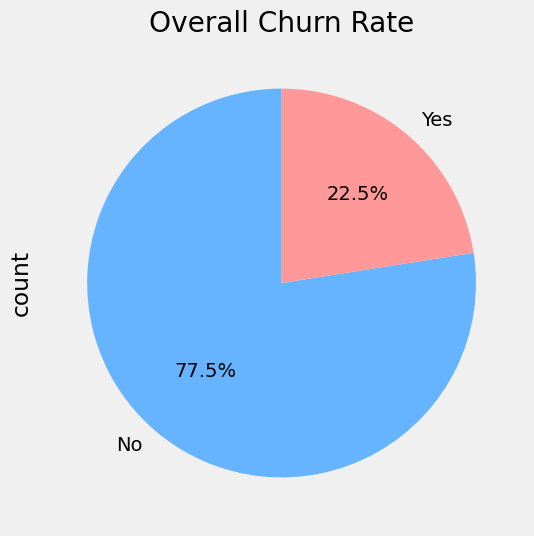

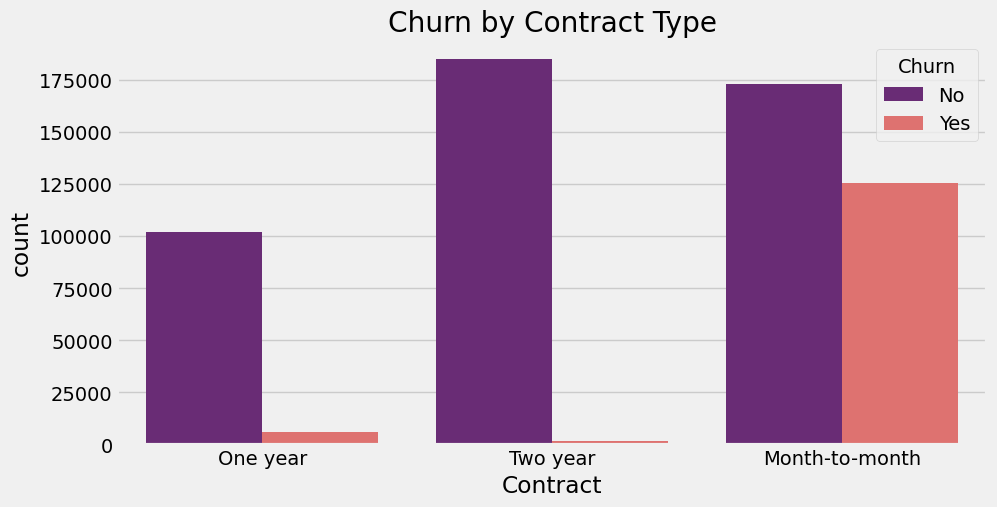

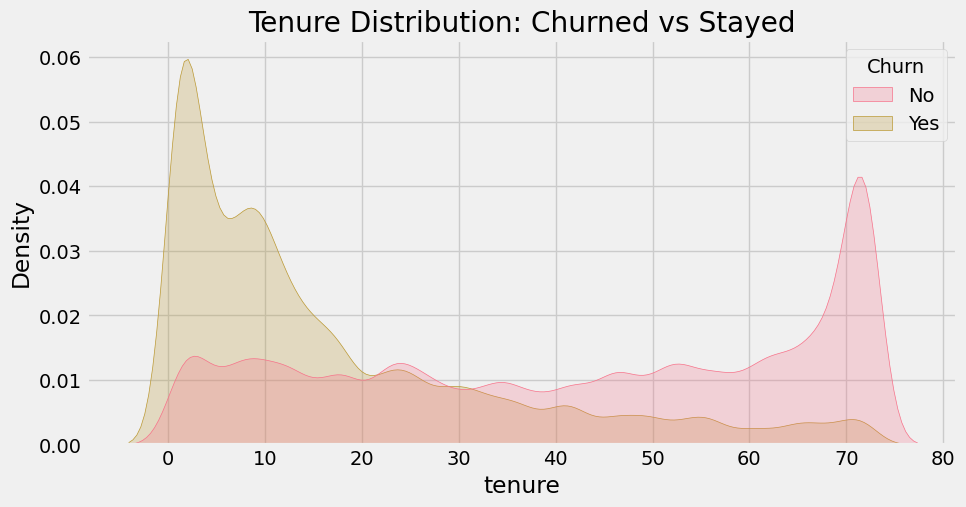

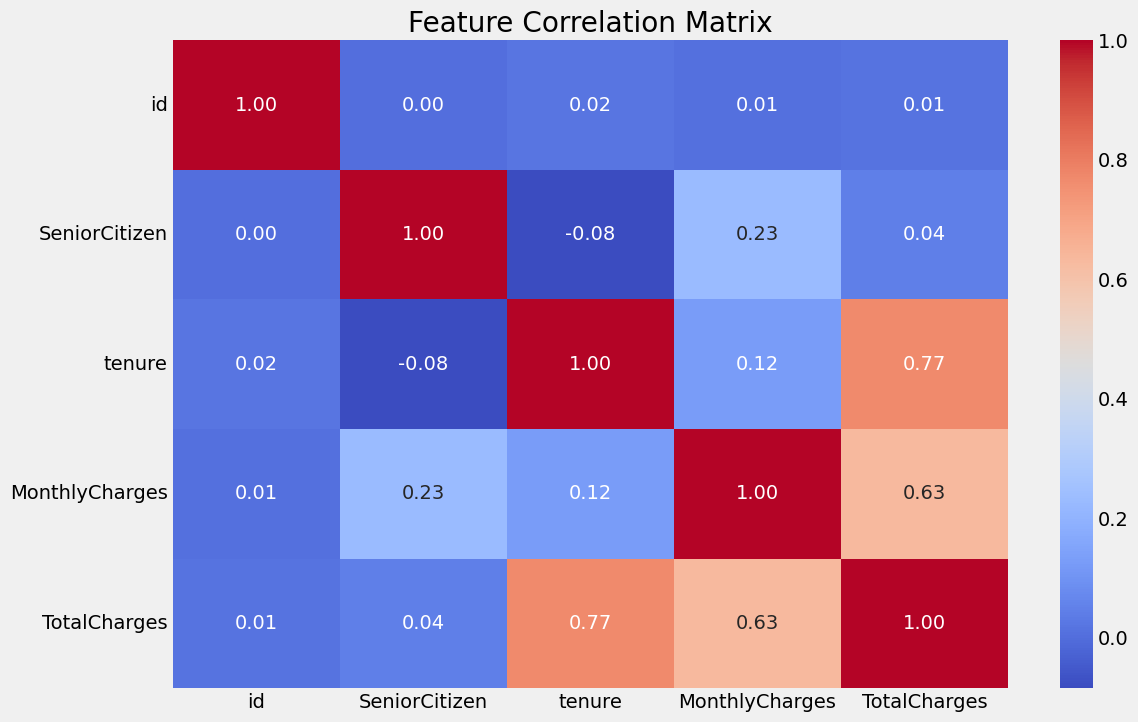

/tmp/ipykernel_18/1810706413.py:35: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Churn', y='MonthlyCharges', data=train, palette='Set2')


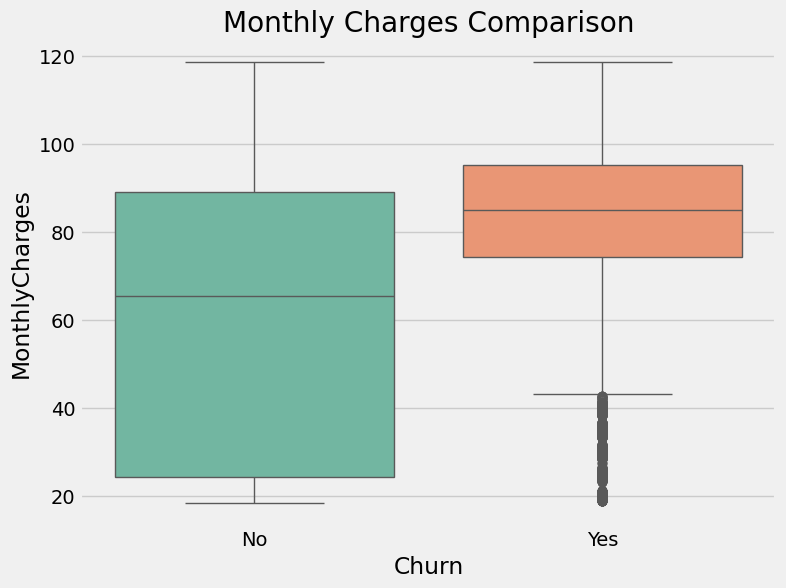

In [3]:
# ====================================================
# 2. DATA LOADING & QUICK EDA
# ====================================================
train = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/train.csv')
test = pd.read_csv('/kaggle/input/competitions/playground-series-s6e3/test.csv')

# Visualizing Churn Distribution:

# 1. Churn Distribution Pie Chart
plt.figure(figsize=(6, 6))
train['Churn'].value_counts().plot.pie(autopct='%1.1f%%', colors=['#66b3ff','#ff9999'], startangle=90)
plt.title('Overall Churn Rate')
plt.show()

# 2. Contract Type vs Churn Bar Chart
plt.figure(figsize=(10, 5))
sns.countplot(x='Contract', hue='Churn', data=train, palette='magma')
plt.title('Churn by Contract Type')
plt.show()

# 3. Tenure KDE Plot
plt.figure(figsize=(10, 5))
sns.kdeplot(data=train, x='tenure', hue='Churn', fill=True, common_norm=False)
plt.title('Tenure Distribution: Churned vs Stayed')
plt.show()

# 4. Correlation Heatmap (Numeric Only)
plt.figure(figsize=(12, 8))
sns.heatmap(train.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Feature Correlation Matrix')
plt.show()

# 5. Monthly Charges Boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x='Churn', y='MonthlyCharges', data=train, palette='Set2')
plt.title('Monthly Charges Comparison')
plt.show()

In [4]:
# ====================================================
# 3. FEATURE ENGINEERING
# ====================================================
def engineer_features(df):
    df = df.copy()
    df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce').fillna(df['MonthlyCharges'] * df['tenure'])
    
    # New Insights
    df['Monthly_Ratio'] = df['MonthlyCharges'] / (df['TotalCharges'] + 1)
    df['Service_Diversity'] = (df[['OnlineSecurity', 'DeviceProtection', 'TechSupport']] == 'Yes').sum(axis=1)
    df['Is_Senior_Fiber'] = ((df['SeniorCitizen'] == 1) & (df['InternetService'] == 'Fiber optic')).astype(int)
    
    for col in df.select_dtypes('object').columns:
        df[col] = df[col].astype('category')
    return df

train_df = engineer_features(train)
test_df = engineer_features(test)

X = train_df.drop(columns=['id', 'Churn'])
y = train_df['Churn'].map({'No': 0, 'Yes': 1})
X_test = test_df.drop(columns=['id'])

print("Feature Engineering: DONE!")

Feature Engineering: DONE!


In [5]:
# ====================================================
# 4. CROSS-VALIDATION LOOP
# ====================================================
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
test_preds = np.zeros(len(test))
importances = []

for fold, (tr_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, X_val = X.iloc[tr_idx], X.iloc[val_idx]
    y_tr, y_val = y.iloc[tr_idx], y.iloc[val_idx]

    model = XGBClassifier(n_estimators=1000, learning_rate=0.05, max_depth=4, 
                          tree_method='hist', device='cuda', enable_categorical=True)
    
    model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], verbose=100)
    test_preds += model.predict_proba(X_test)[:, 1] / 5
    importances.append(model.feature_importances_)

print ("CV DONE!")

[0]	validation_0-logloss:0.51416


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:34:55] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:34:55] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.30494
[200]	validation_0-logloss:0.30166
[300]	validation_0-logloss:0.30031
[400]	validation_0-logloss:0.29961
[500]	validation_0-logloss:0.29921
[600]	validation_0-logloss:0.29889
[700]	validation_0-logloss:0.29873
[800]	validation_0-logloss:0.29854
[900]	validation_0-logloss:0.29842
[999]	validation_0-logloss:0.29835
[0]	validation_0-logloss:0.51397


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:35:42] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:35:42] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.30308
[200]	validation_0-logloss:0.29976
[300]	validation_0-logloss:0.29849
[400]	validation_0-logloss:0.29770
[500]	validation_0-logloss:0.29731
[600]	validation_0-logloss:0.29704
[700]	validation_0-logloss:0.29682
[800]	validation_0-logloss:0.29669
[900]	validation_0-logloss:0.29663
[999]	validation_0-logloss:0.29651
[0]	validation_0-logloss:0.51406


...

[100]	validation_0-logloss:0.30444
[200]	validation_0-logloss:0.30133
[300]	validation_0-logloss:0.30007
[400]	validation_0-logloss:0.29927
[500]	validation_0-logloss:0.29878
[600]	validation_0-logloss:0.29841
[700]	validation_0-logloss:0.29819
[800]	validation_0-logloss:0.29799
[900]	validation_0-logloss:0.29791
[999]	validation_0-logloss:0.29779
[0]	validation_0-logloss:0.51405


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:37:13] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:37:13] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.30262
[200]	validation_0-logloss:0.29937
[300]	validation_0-logloss:0.29816
[400]	validation_0-logloss:0.29746
[500]	validation_0-logloss:0.29709
[600]	validation_0-logloss:0.29679
[700]	validation_0-logloss:0.29650
[800]	validation_0-logloss:0.29634
[900]	validation_0-logloss:0.29625
[999]	validation_0-logloss:0.29623
[0]	validation_0-logloss:0.51416


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:37:59] WARNING: /workspace/src/context.cc:53: No visible GPU is found, setting device to CPU.
  bst.update(dtrain, iteration=i, fobj=obj)
/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [09:37:59] WARNING: /workspace/src/context.cc:207: Device is changed from GPU to CPU as we couldn't find any available GPU on the system.
  bst.update(dtrain, iteration=i, fobj=obj)


[100]	validation_0-logloss:0.30698
[200]	validation_0-logloss:0.30385
[300]	validation_0-logloss:0.30240
[400]	validation_0-logloss:0.30170
[500]	validation_0-logloss:0.30130
[600]	validation_0-logloss:0.30097
[700]	validation_0-logloss:0.30075
[800]	validation_0-logloss:0.30061
[900]	validation_0-logloss:0.30048
[999]	validation_0-logloss:0.30039
CV DONE!


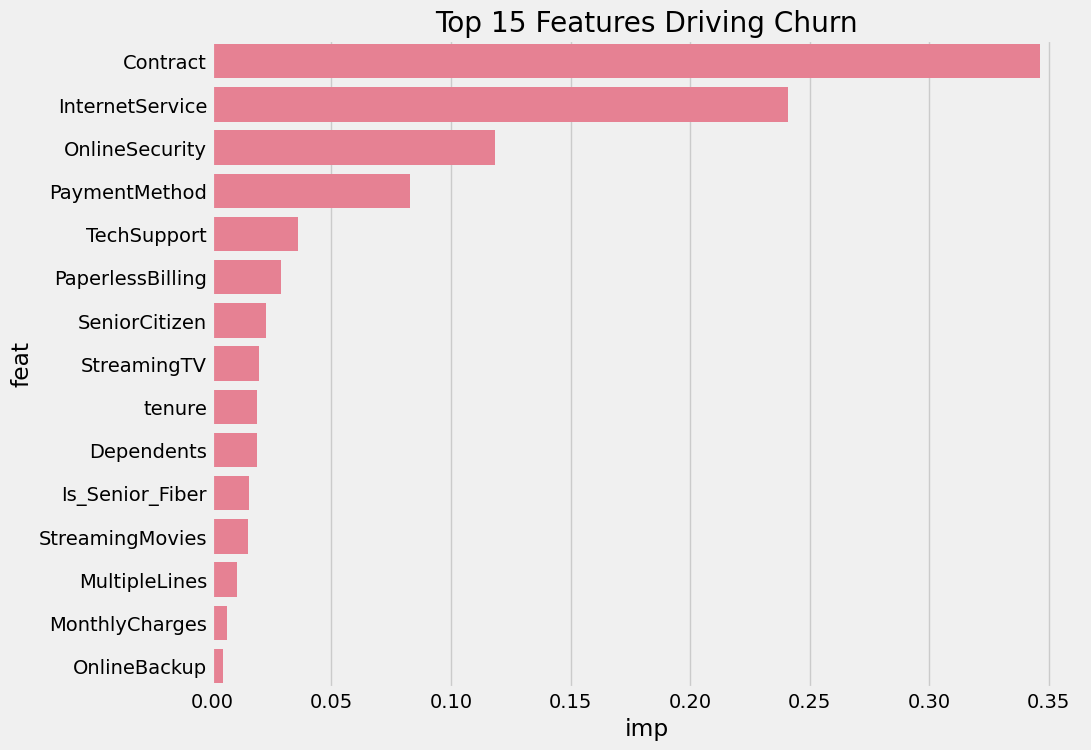

submission.csv file is ready!


In [6]:
# ====================================================
# 5. FEATURE IMPORTANCE (Upvote Magnet #2)
# ====================================================
fi_df = pd.DataFrame({'feat': X.columns, 'imp': np.mean(importances, axis=0)}).sort_values('imp', ascending=False)
plt.figure(figsize=(10, 8))
sns.barplot(data=fi_df.head(15), x='imp', y='feat')
plt.title('Top 15 Features Driving Churn')
plt.show()

pd.DataFrame({'id': test['id'], 'Churn': test_preds}).to_csv('submission.csv', index=False)
print("submission.csv file is ready!")